In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/system-log-unsupervised-ml')
os.getcwd()


'/content/drive/MyDrive/system-log-unsupervised-ml'

In [3]:
os.listdir()


['data', 'notebooks', 'results', 'report']

# System Log and Resource Usage Pattern Analysis
## Notebook 01: Data Exploration

This notebook focuses on generating and exploring unlabelled system metrics data
including CPU, memory, disk I/O, network I/O, and system load to understand
baseline system behaviour prior to applying unsupervised learning techniques.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [6]:
np.random.seed(42)

n_samples = 2000

timestamps = pd.date_range(
    start="2025-01-01",
    periods=n_samples,
    freq="T"
)

cpu_usage = np.random.normal(loc=45, scale=15, size=n_samples).clip(0, 100)
memory_usage = np.random.normal(loc=60, scale=10, size=n_samples).clip(0, 100)
disk_io = np.random.normal(loc=120, scale=40, size=n_samples).clip(0)
network_io = np.random.normal(loc=300, scale=80, size=n_samples).clip(0)
system_load = np.random.normal(loc=1.5, scale=0.6, size=n_samples).clip(0)

df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_usage": cpu_usage,
    "memory_usage": memory_usage,
    "disk_io": disk_io,
    "network_io": network_io,
    "system_load": system_load
})

df.head()


/tmp/ipython-input-3983760842.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(


,timestamp,cpu_usage,memory_usage,disk_io,network_io,system_load
0,2025-01-01 00:00:00,52.450712,53.248217,85.460256,210.873491,1.480185
1,2025-01-01 00:01:00,42.926035,58.554813,118.751860,249.525533,1.197810
2,2025-01-01 00:02:00,54.715328,52.075801,120.720675,224.635185,1.396575
3,2025-01-01 00:03:00,67.845448,56.920385,138.905214,256.160335,1.928839
4,2025-01-01 00:04:00,41.487699,41.063853,65.325665,282.867975,2.266714


In [7]:
df.to_csv("data/raw/system_metrics.csv", index=False)


In [8]:
import os

os.listdir("data/raw")


['system_metrics.csv']

In [9]:
df.shape

(2000, 6)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     2000 non-null   datetime64[ns]
 1   cpu_usage     2000 non-null   float64       
 2   memory_usage  2000 non-null   float64       
 3   disk_io       2000 non-null   float64       
 4   network_io    2000 non-null   float64       
 5   system_load   2000 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 93.9 KB


In [11]:
df.describe()


,timestamp,cpu_usage,memory_usage,disk_io,network_io,system_load
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2025-01-01 16:39:29.999999744,45.676676,59.935575,118.086870,299.642421,1.503447
min,2025-01-01 00:00:00,0.000000,29.804878,0.000000,4.930777,0.000000
25%,2025-01-01 08:19:45,35.660071,52.908740,92.528399,241.973497,1.116188
50%,2025-01-01 16:39:30,45.670375,59.999467,118.791602,297.558018,1.508519
75%,2025-01-02 00:59:15,55.244664,66.655437,145.152731,356.829984,1.897516
max,2025-01-02 09:19:00,100.000000,99.262377,244.516408,582.324415,3.526430
std,NaN,14.815936,10.053541,39.964970,82.673540,0.588394


### Observations (Initial Data Exploration)

- The dataset contains time-based system metrics with 2000 samples.
- All metrics are numerical and continuous, suitable for unsupervised learning.
- No missing values are present in the generated dataset.
- CPU and memory usage exhibit realistic variability across time.


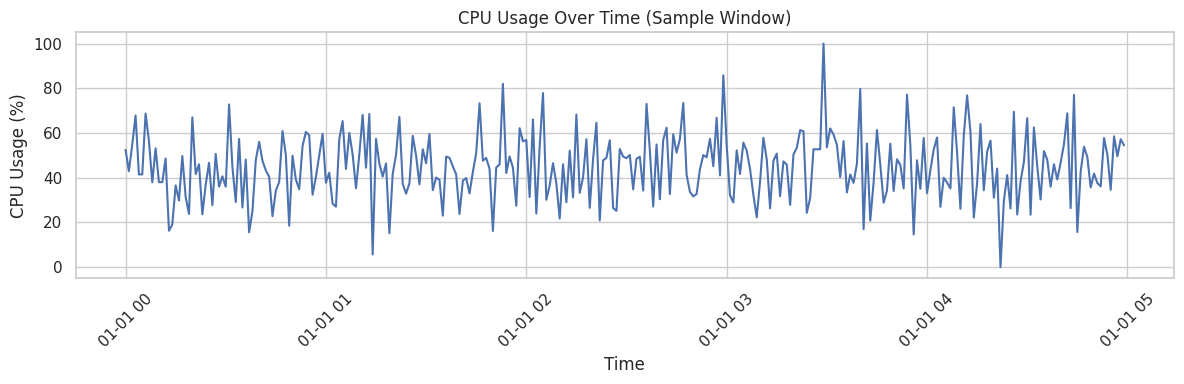

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"][:300], df["cpu_usage"][:300])
plt.title("CPU Usage Over Time (Sample Window)")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


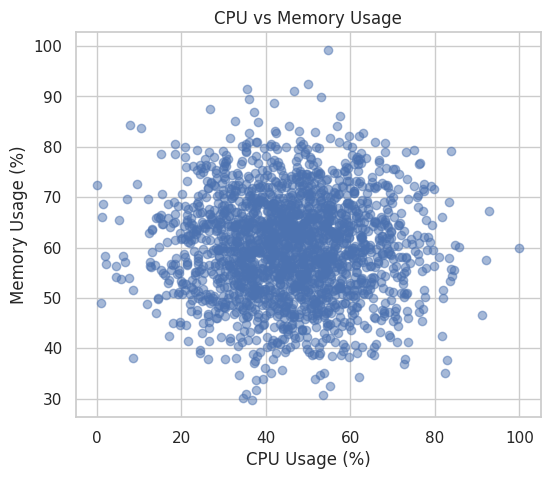

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(df["cpu_usage"], df["memory_usage"], alpha=0.5)
plt.xlabel("CPU Usage (%)")
plt.ylabel("Memory Usage (%)")
plt.title("CPU vs Memory Usage")
plt.show()


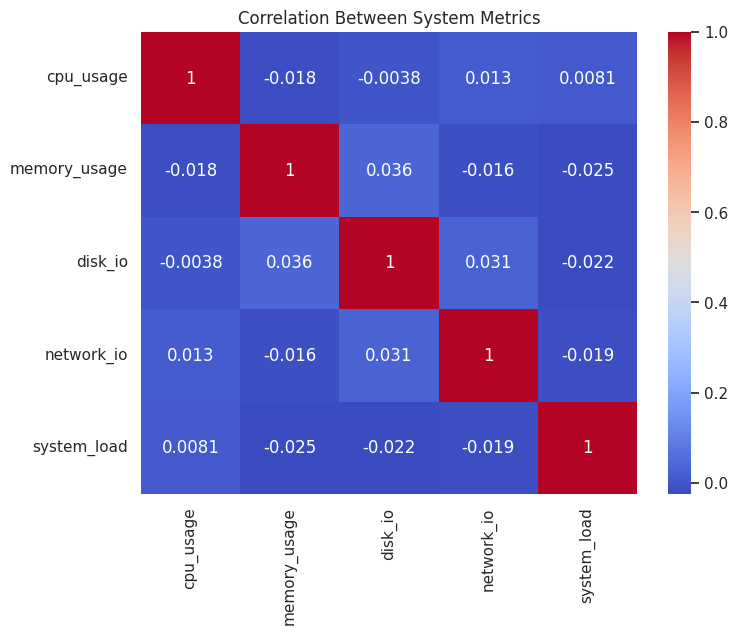

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.drop(columns=["timestamp"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between System Metrics")
plt.show()


### Observations from Visualization

- CPU usage fluctuates over time, indicating dynamic workload patterns.
- CPU and memory usage show moderate positive correlation.
- Disk I/O and network I/O vary more independently.
- The absence of labelled outcomes supports the use of unsupervised learning.
